# CE639: AI for Civil Engineering
## Lecture 03: Probability & Statistics
### Scientific Computing Fundamentals

**Instructors:** Dr. Udit Bhatia & Dr. Sushobhan Sen  
**Tutor:** Sarth Dubey  
**Institution:** IIT Gandhinagar

---

### Learning Objectives

By the end of this notebook, you will be able to:
- Define random variables and their probability distributions
- Evaluate measures of central tendency (mean, variance, skewness, kurtosis)
- Model behavior in extremes using GEV distributions
- Apply probability concepts to Civil Engineering problems

## 🔧 Setup and Installation

In [1]:
# Install dependencies (for Google Colab)
import sys
import subprocess

def install_package(package):
    """Install a package using pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

# # Install required packages
# required_packages = ['numpy', 'matplotlib', 'scipy', 'ipywidgets', 'pandas']
# for package in required_packages:
#     try:
#         __import__(package)
#     except ImportError:
#         print(f"Installing {package}...")
#         install_package(package)

print("\n✓ All packages installed successfully!")

Running locally ✓

✓ All packages installed successfully!


In [2]:
# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats, special
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
%matplotlib inline

# Import our custom helper utilities
import sys
sys.path.append('/content')  # For Colab
sys.path.append('..')  # For local

from utils.Lecture_03 import (
    # Distributions
    uniform_pdf, uniform_cdf, normal_pdf, normal_cdf,
    gumbel_pdf, gumbel_cdf, gev_pdf, gev_cdf, compute_moments,
    # Visualizations
    plot_pmf, plot_pdf, plot_cdf, plot_distribution_comparison,
    animate_sampling, plot_covariance_matrix, plot_correlation_scatter, animate_clt,
    # Widgets
    distribution_explorer_widget, sampling_widget, covariance_widget,
    extreme_value_widget, moments_explorer_widget,
    # CE Examples
    generate_concrete_strength_data, generate_flood_data, generate_sensor_noise,
    generate_load_data, generate_wind_speed_data, generate_correlated_data
)

print("✓ All imports successful!")
print("=" * 70)
print("Ready to explore Probability & Statistics!")
print("=" * 70)

✓ All imports successful!
Ready to explore Probability & Statistics!


# 📊 Section 1: Motivation - Why Probability?

## Non-Deterministic Systems

In Civil Engineering, we often deal with **uncertainty**:
- Material properties vary (concrete strength, steel yield stress)
- Loads are unpredictable (wind, earthquakes, traffic)
- Environmental conditions fluctuate (temperature, humidity)
- Measurements contain noise (sensor errors)

**Key Question:** How do we make reliable decisions when we can't predict exact outcomes?

**Answer:** Probability theory provides a mathematical framework to quantify and manage uncertainty.

### CE Examples of Non-Deterministic Systems

1. **Structural Loads:** Live loads on buildings vary with occupancy
2. **Flood Events:** Annual peak discharge varies year to year
3. **Material Strength:** Concrete compressive strength has variability
4. **Sensor Measurements:** Temperature sensors have noise
5. **Extreme Events:** Earthquakes, hurricanes (rare but high-impact)

# 🎲 Section 2: Random Variables

## What is a Random Variable?

A **random variable (RV)** is a function that maps outcomes of a random experiment to real numbers.

**Formally:** $X: \Omega \rightarrow \mathbb{R}$

where $\Omega$ is the **sample space** (all possible outcomes).

**Example:** Coin toss
- Sample space: $\Omega = \{\text{Heads}, \text{Tails}\}$
- Random variable: $X(\text{Heads}) = 0$, $X(\text{Tails}) = 1$

In [3]:
# Simple example: Coin toss simulation
np.random.seed(42)
n_tosses = 10

# Simulate coin tosses (0 = Heads, 1 = Tails)
tosses = np.random.randint(0, 2, n_tosses)

print("Coin Toss Simulation:")
print(f"  Tosses: {tosses}")
print(f"  Number of Heads: {np.sum(tosses == 0)}")
print(f"  Number of Tails: {np.sum(tosses == 1)}")
print(f"  Proportion of Heads: {np.mean(tosses == 0):.2f}")

Coin Toss Simulation:
  Tosses: [0 1 0 0 0 1 0 0 0 1]
  Number of Heads: 7
  Number of Tails: 3
  Proportion of Heads: 0.70


## Types of Random Variables

### 1. Discrete Random Variables
- Take values from a **finite or countable** set
- Examples: Number of cars on a bridge, dice roll, pass/fail

### 2. Continuous Random Variables  
- Can take **any value** in an interval
- Examples: Temperature, beam deflection, wind speed

In [4]:
# Discrete RV example: Number of defects in concrete samples
defects = np.array([0, 1, 0, 2, 1, 0, 3, 1, 0, 1, 2, 0, 1, 0, 0])

print("Discrete Random Variable Example:")
print(f"  Defects per sample: {defects}")
print(f"  Unique values: {np.unique(defects)}")
print(f"  Mean defects: {np.mean(defects):.2f}")

Discrete Random Variable Example:
  Defects per sample: [0 1 0 2 1 0 3 1 0 1 2 0 1 0 0]
  Unique values: [0 1 2 3]
  Mean defects: 0.80


In [5]:
# Continuous RV example: Concrete compressive strength
strengths = np.array([28.5, 31.2, 29.8, 30.5, 32.1, 27.9, 30.8, 29.5, 31.5, 28.9])

print("Continuous Random Variable Example:")
print(f"  Strengths (MPa): {strengths}")
print(f"  Mean strength: {np.mean(strengths):.2f} MPa")
print(f"  Std deviation: {np.std(strengths, ddof=1):.2f} MPa")

Continuous Random Variable Example:
  Strengths (MPa): [28.5 31.2 29.8 30.5 32.1 27.9 30.8 29.5 31.5 28.9]
  Mean strength: 30.07 MPa
  Std deviation: 1.38 MPa


# 📈 Section 3: Probability Mass Function (PMF)

## PMF for Discrete Random Variables

The **Probability Mass Function** gives the probability that a discrete RV takes a specific value:

$$p(X = x_i) = P(X = x_i)$$

**Properties:**
- $0 \leq p(x_i) \leq 1$ for all $i$
- $\sum_i p(x_i) = 1$ (probabilities sum to 1)

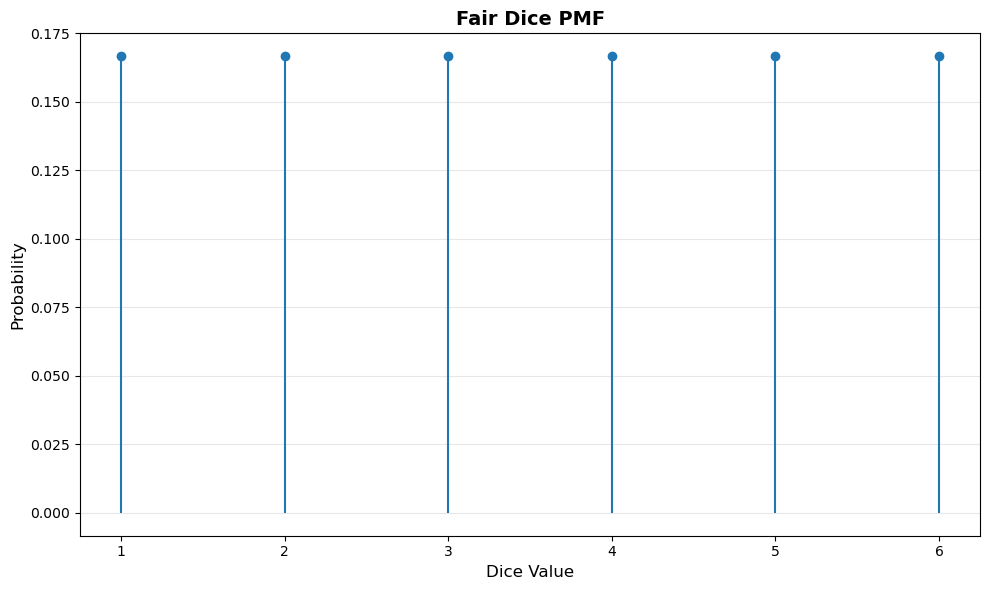

Fair Dice PMF:
  P(X = 1) = 0.1667
  P(X = 2) = 0.1667
  P(X = 3) = 0.1667
  P(X = 4) = 0.1667
  P(X = 5) = 0.1667
  P(X = 6) = 0.1667


In [6]:
# Example: Dice roll PMF
dice_values = np.arange(1, 7)
dice_probabilities = np.ones(6) / 6  # Fair dice

fig, ax = plot_pmf(dice_values, dice_probabilities, 
                   title="Fair Dice PMF", xlabel="Dice Value")
plt.show()

print("Fair Dice PMF:")
for val, prob in zip(dice_values, dice_probabilities):
    print(f"  P(X = {val}) = {prob:.4f}")

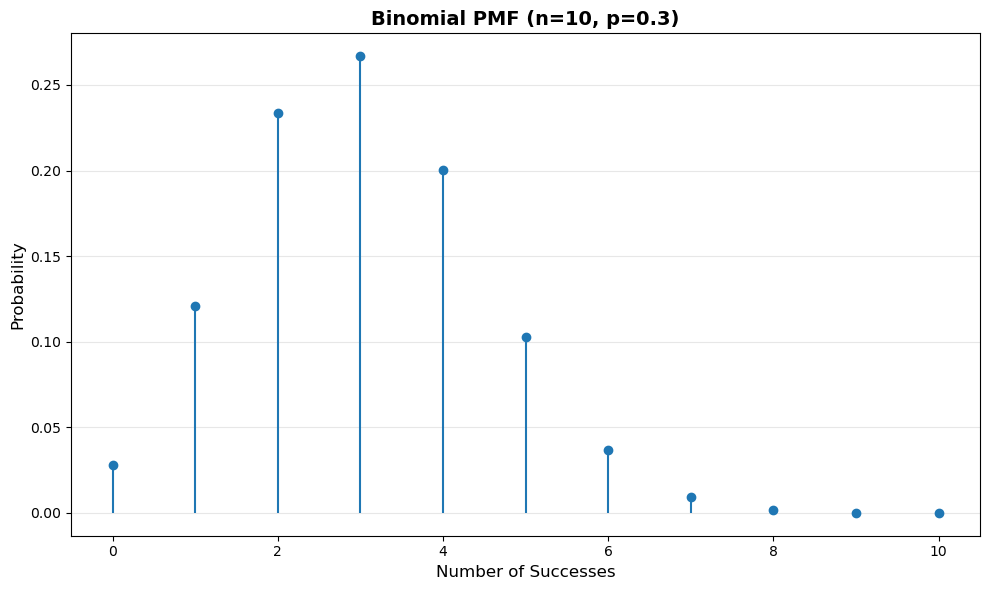


Binomial Distribution (n=10, p=0.3):
  Expected value: 3.00
  Variance: 2.10


In [7]:
# Example: Binomial distribution (number of successes in n trials)
n_trials = 10
p_success = 0.3

# Calculate PMF using scipy
x_values = np.arange(0, n_trials + 1)
pmf_values = stats.binom.pmf(x_values, n_trials, p_success)

fig, ax = plot_pmf(x_values, pmf_values,
                   title=f"Binomial PMF (n={n_trials}, p={p_success})",
                   xlabel="Number of Successes")
plt.show()

print(f"\nBinomial Distribution (n={n_trials}, p={p_success}):")
print(f"  Expected value: {n_trials * p_success:.2f}")
print(f"  Variance: {n_trials * p_success * (1 - p_success):.2f}")

# 📉 Section 4: Probability Density Function (PDF)

## PDF for Continuous Random Variables

For continuous RVs, we use the **Probability Density Function**:

$$p(a \leq X \leq b) = \int_a^b p(x) \, dx$$

**Important:** For continuous RVs, $P(X = x) = 0$ (probability at a single point is zero!)

**Properties:**
- $p(x) \geq 0$ for all $x$
- $\int_{-\infty}^{\infty} p(x) \, dx = 1$

### Uniform Distribution

The simplest continuous distribution - all values equally likely in $[a, b]$:

$$p(x) = \begin{cases} \frac{1}{b-a} & a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}$$

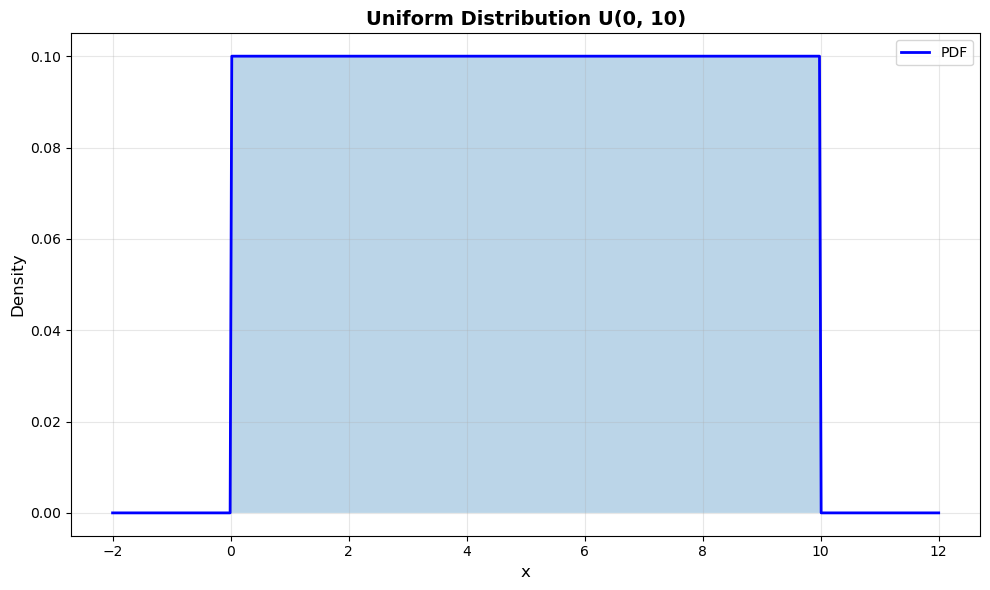

Uniform Distribution U(0, 10):
  Mean: 5.00
  Variance: 8.33


In [8]:
# Uniform distribution
a, b = 0, 10
x = np.linspace(-2, 12, 500)
pdf = uniform_pdf(x, a, b)

fig, ax = plot_pdf(x, pdf, title=f"Uniform Distribution U({a}, {b})",
                   xlabel="x", ylabel="Density")
plt.show()

print(f"Uniform Distribution U({a}, {b}):")
print(f"  Mean: {(a + b) / 2:.2f}")
print(f"  Variance: {(b - a)**2 / 12:.2f}")

### Normal (Gaussian) Distribution

The most important distribution in statistics:

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$: mean (location)
- $\sigma$: standard deviation (spread)

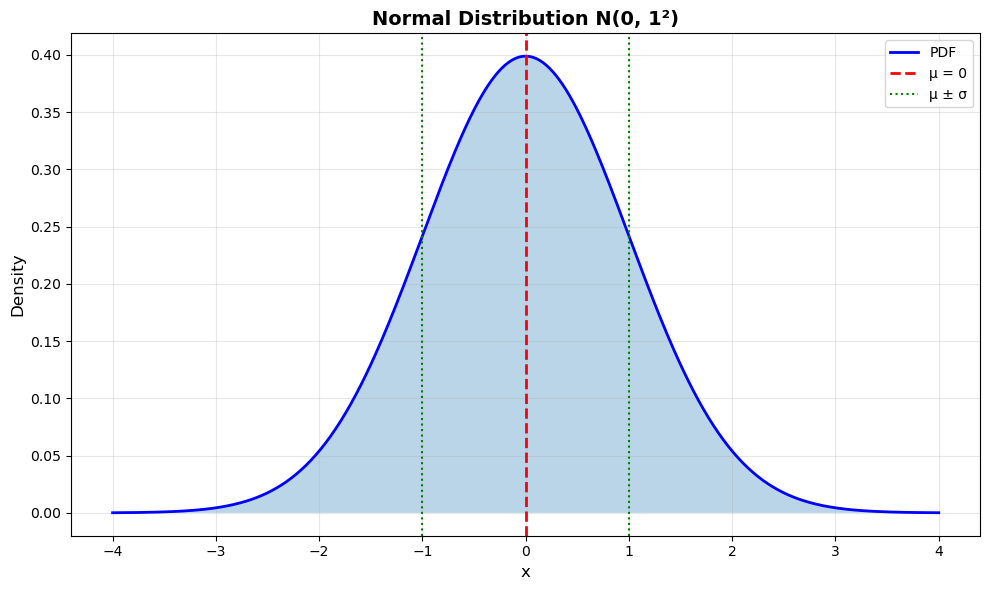

Normal Distribution N(0, 1²):
  68% of data within μ ± σ
  95% of data within μ ± 2σ
  99.7% of data within μ ± 3σ


In [9]:
# Normal distribution
mu, sigma = 0, 1
x = np.linspace(-4, 4, 500)
pdf = normal_pdf(x, mu, sigma)

fig, ax = plot_pdf(x, pdf, title=f"Normal Distribution N({mu}, {sigma}²)",
                   xlabel="x", ylabel="Density")

# Add vertical lines for mean and std dev
ax.axvline(mu, color='r', linestyle='--', linewidth=2, label=f'μ = {mu}')
ax.axvline(mu - sigma, color='g', linestyle=':', linewidth=1.5, label='μ ± σ')
ax.axvline(mu + sigma, color='g', linestyle=':', linewidth=1.5)
ax.legend()

plt.show()

print(f"Normal Distribution N({mu}, {sigma}²):")
print(f"  68% of data within μ ± σ")
print(f"  95% of data within μ ± 2σ")
print(f"  99.7% of data within μ ± 3σ")

### 🎮 Interactive Widget: Distribution Explorer

In [ ]:
distribution_explorer_widget(dist_type='normal')

interactive(children=(FloatSlider(value=0.0, description='Mean (μ):', max=10.0, min=-10.0, step=0.5, style=Sli…

# 📊 Section 5: Cumulative Distribution Function (CDF)

## CDF Definition

The **Cumulative Distribution Function** gives the probability that X is less than or equal to x:

$$F(x) = P(X \leq x)$$

**For discrete RVs:**
$$F(x) = \sum_{t \leq x} p(X = t)$$

**For continuous RVs:**
$$F(x) = \int_{-\infty}^{x} p(t) \, dt$$

**Relationship:** $p(x) = F'(x)$ (PDF is derivative of CDF)

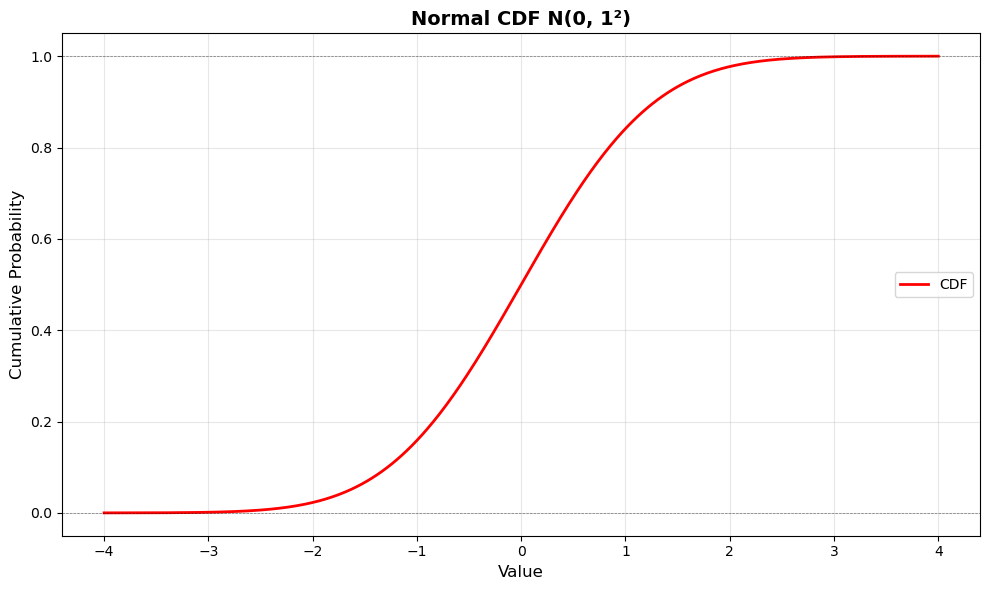

Using CDF to calculate probabilities:
  P(X ≤ 1) = 0.8413
  P(-1 ≤ X ≤ 1) = 0.6827


In [11]:
# Normal CDF
mu, sigma = 0, 1
x = np.linspace(-4, 4, 500)
cdf = normal_cdf(x, mu, sigma)

fig, ax = plot_cdf(x, cdf, title=f"Normal CDF N({mu}, {sigma}²)")
plt.show()

# Calculate probabilities using CDF
prob_less_than_1 = normal_cdf(1, mu, sigma)
prob_between = normal_cdf(1, mu, sigma) - normal_cdf(-1, mu, sigma)

print("Using CDF to calculate probabilities:")
print(f"  P(X ≤ 1) = {prob_less_than_1:.4f}")
print(f"  P(-1 ≤ X ≤ 1) = {prob_between:.4f}")

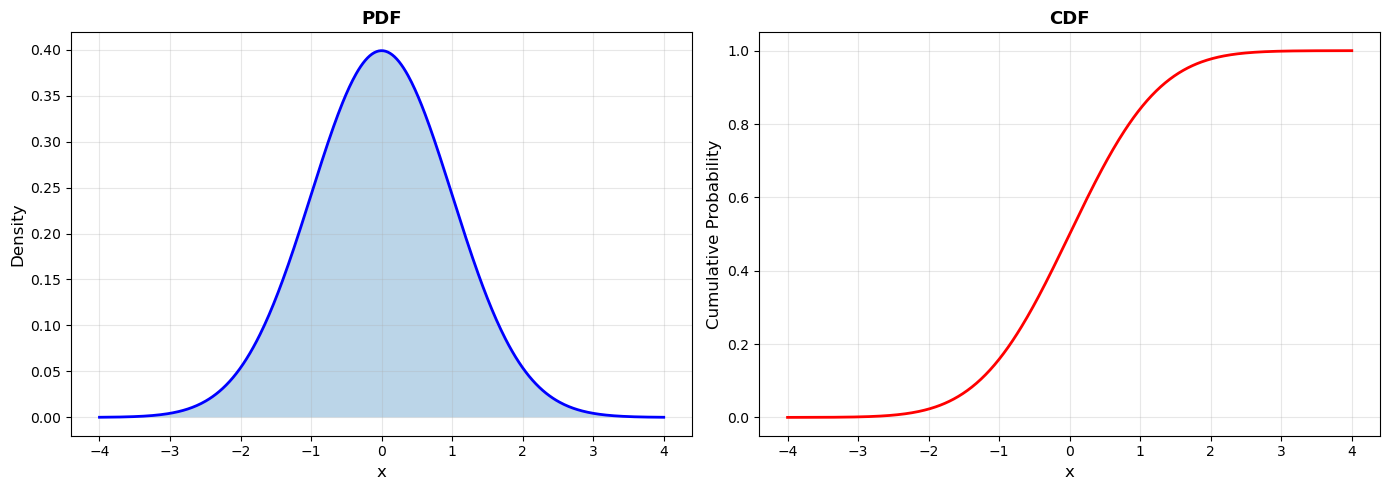

In [12]:
# Compare PDF and CDF side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PDF
pdf = normal_pdf(x, mu, sigma)
ax1.plot(x, pdf, 'b-', linewidth=2)
ax1.fill_between(x, pdf, alpha=0.3)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('PDF', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# CDF
ax2.plot(x, cdf, 'r-', linewidth=2)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('CDF', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🎯 Section 6: Expected Value (Mean)

## Expected Value Definition

The **expected value** (or **mean**) is the long-run average:

**Discrete:** $E[X] = \sum_x x \cdot p(X = x)$

**Continuous:** $E[X] = \int_{-\infty}^{\infty} x \cdot p(x) \, dx$

**Interpretation:** Center of mass of the distribution

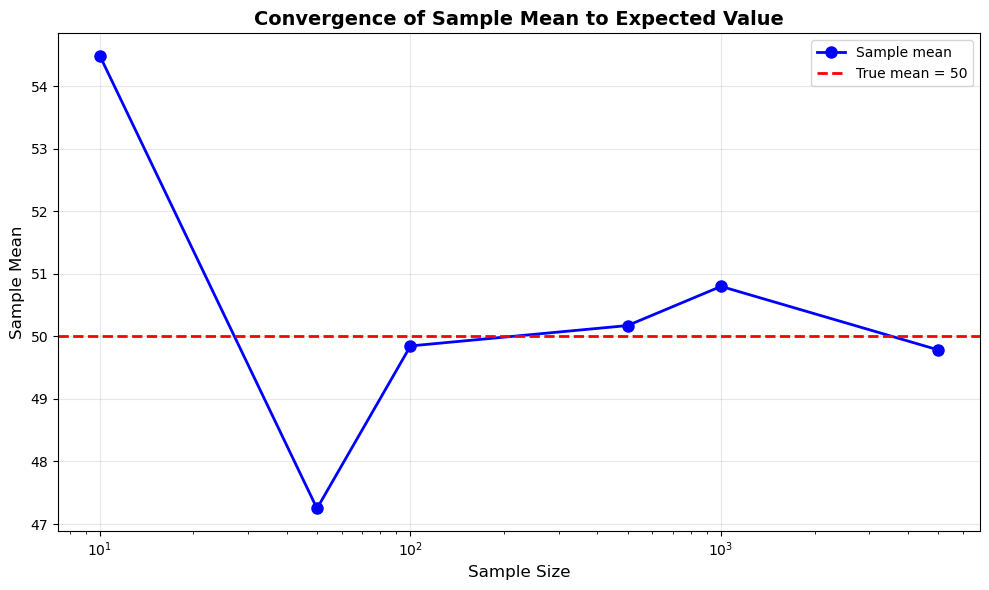

Sample Mean Convergence:
  n =    10: mean =  54.48, error = 4.4806
  n =    50: mean =  47.25, error = 2.7520
  n =   100: mean =  49.85, error = 0.1537
  n =   500: mean =  50.17, error = 0.1717
  n =  1000: mean =  50.80, error = 0.7979
  n =  5000: mean =  49.78, error = 0.2166


In [13]:
# Demonstrate expected value through sampling
np.random.seed(42)
mu_true = 50
sigma_true = 10

# Sample sizes
sample_sizes = [10, 50, 100, 500, 1000, 5000]
sample_means = []

for n in sample_sizes:
    samples = np.random.normal(mu_true, sigma_true, n)
    sample_means.append(np.mean(samples))

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, sample_means, 'bo-', linewidth=2, markersize=8, label='Sample mean')
ax.axhline(mu_true, color='r', linestyle='--', linewidth=2, label=f'True mean = {mu_true}')
ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Sample Mean', fontsize=12)
ax.set_title('Convergence of Sample Mean to Expected Value', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Sample Mean Convergence:")
for n, mean in zip(sample_sizes, sample_means):
    error = abs(mean - mu_true)
    print(f"  n = {n:5d}: mean = {mean:6.2f}, error = {error:.4f}")

### Properties of Expectation

1. **Linearity:** $E[aX + bY] = aE[X] + bE[Y]$
2. **Constant:** $E[c] = c$
3. **Function:** $E[g(X)] = \int g(x) p(x) \, dx$

In [14]:
# Demonstrate linearity
X = np.random.randn(10000)
Y = np.random.randn(10000)
a, b = 2, 3

# E[aX + bY] = aE[X] + bE[Y]
lhs = np.mean(a * X + b * Y)
rhs = a * np.mean(X) + b * np.mean(Y)

print("Linearity of Expectation:")
print(f"  E[{a}X + {b}Y] = {lhs:.4f}")
print(f"  {a}E[X] + {b}E[Y] = {rhs:.4f}")
print(f"  Difference: {abs(lhs - rhs):.6f}")

Linearity of Expectation:
  E[2X + 3Y] = 0.0256
  2E[X] + 3E[Y] = 0.0256
  Difference: 0.000000


## Variance Definition

**Variance** measures the spread of data around the mean:

$$\text{Var}(X) = \sigma^2 = E[(X - \mu)^2]$$

**Alternative form:** $\text{Var}(X) = E[X^2] - (E[X])^2$

**Standard deviation:** $\sigma = \sqrt{\text{Var}(X)}$

**Properties:**
- $\text{Var}(aX + b) = a^2 \text{Var}(X)$ (shifting doesn't change variance, scaling amplifies quadratically)

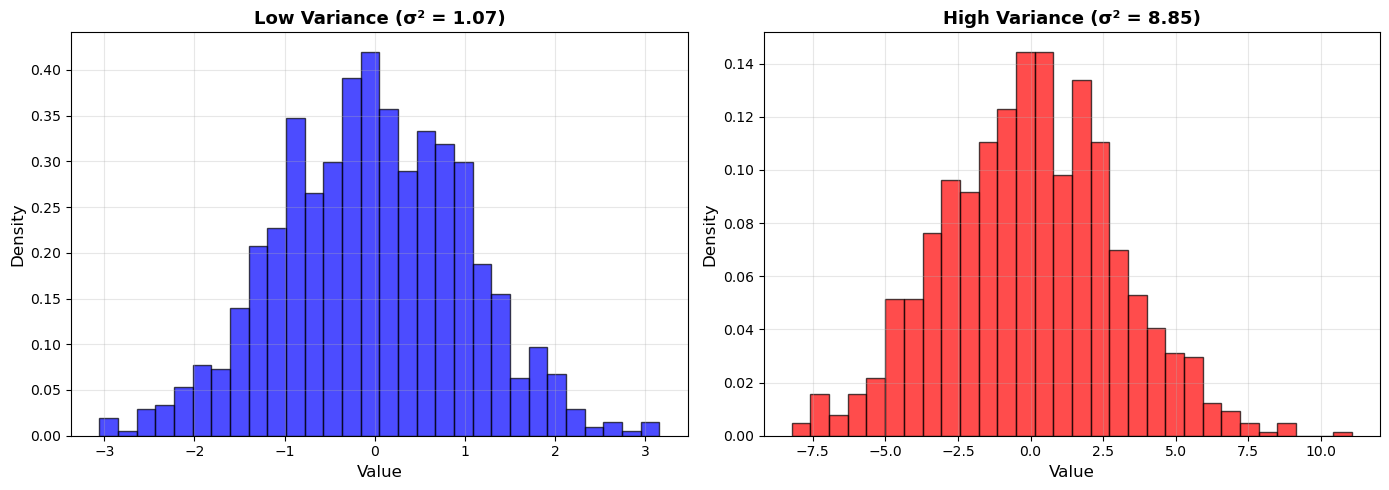

Variance Comparison:
  Data 1: mean = -0.03, variance = 1.07
  Data 2: mean = -0.03, variance = 8.85


In [15]:
# Demonstrate variance
data1 = np.random.normal(0, 1, 1000)  # Low variance
data2 = np.random.normal(0, 3, 1000)  # High variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Low variance
ax1.hist(data1, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title(f'Low Variance (σ² = {np.var(data1, ddof=1):.2f})', 
             fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# High variance
ax2.hist(data2, bins=30, density=True, alpha=0.7, color='red', edgecolor='black')
ax2.set_xlabel('Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(f'High Variance (σ² = {np.var(data2, ddof=1):.2f})', 
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Variance Comparison:")
print(f"  Data 1: mean = {np.mean(data1):.2f}, variance = {np.var(data1, ddof=1):.2f}")
print(f"  Data 2: mean = {np.mean(data2):.2f}, variance = {np.var(data2, ddof=1):.2f}")

In [16]:
# Demonstrate scaling property
X = np.random.randn(10000)
a = 2

var_X = np.var(X, ddof=1)
var_aX = np.var(a * X, ddof=1)

print("Variance Scaling Property:")
print(f"  Var(X) = {var_X:.4f}")
print(f"  Var({a}X) = {var_aX:.4f}")
print(f"  {a}² × Var(X) = {a**2 * var_X:.4f}")
print(f"  Match? {np.isclose(var_aX, a**2 * var_X)}")

Variance Scaling Property:
  Var(X) = 1.0091
  Var(2X) = 4.0363
  2² × Var(X) = 4.0363
  Match? True


### 🎮 Interactive Widget: Sampling Explorer

In [17]:
sampling_widget()

interactive(children=(IntSlider(value=100, description='Sample Size:', max=10000, min=10, step=10, style=Slide…

# 📊 Section 8: Higher Moments - Skewness & Kurtosis

## Skewness

**Skewness** measures asymmetry of the distribution:

$$\text{Skewness} = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right]$$

- **Skewness > 0:** Right-skewed (long right tail)
- **Skewness < 0:** Left-skewed (long left tail)
- **Skewness ≈ 0:** Symmetric

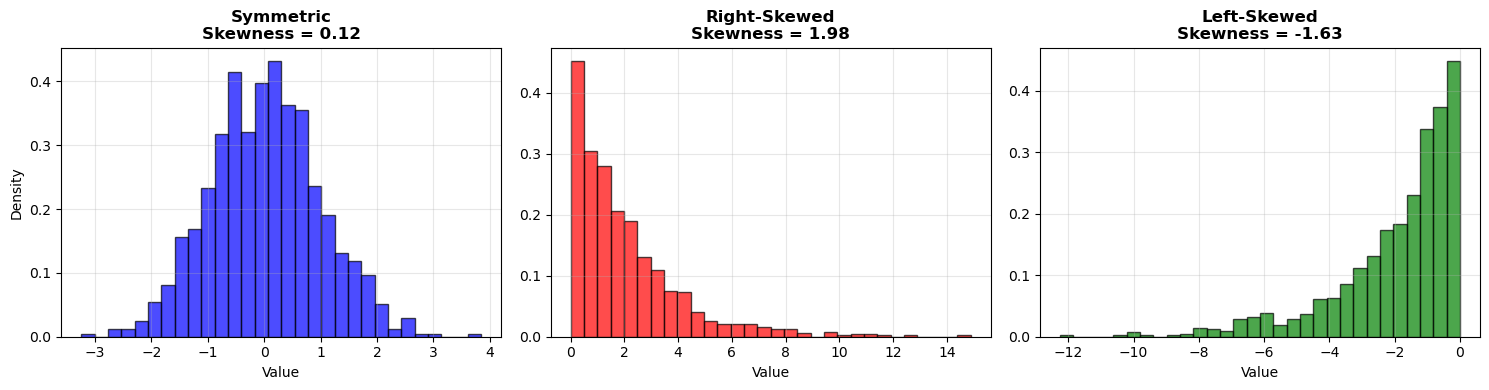

In [18]:
# Generate data with different skewness
np.random.seed(42)

# Symmetric (normal)
symmetric = np.random.normal(0, 1, 1000)

# Right-skewed (exponential)
right_skewed = np.random.exponential(2, 1000)

# Left-skewed (negative exponential)
left_skewed = -np.random.exponential(2, 1000)

# Calculate moments
from utils.Lecture_03 import compute_moments

_, _, skew_sym, _ = compute_moments(symmetric)
_, _, skew_right, _ = compute_moments(right_skewed)
_, _, skew_left, _ = compute_moments(left_skewed)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(symmetric, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title(f'Symmetric\nSkewness = {skew_sym:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

axes[1].hist(right_skewed, bins=30, density=True, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title(f'Right-Skewed\nSkewness = {skew_right:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].grid(True, alpha=0.3)

axes[2].hist(left_skewed, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Left-Skewed\nSkewness = {skew_left:.2f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Kurtosis

**Kurtosis** measures tail heaviness (outlier likelihood):

$$\text{Kurtosis} = E\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] - 3$$

(The -3 makes normal distribution have kurtosis = 0)

- **Kurtosis > 0:** Heavy tails (more outliers than normal)
- **Kurtosis < 0:** Light tails (fewer outliers than normal)
- **Kurtosis ≈ 0:** Normal-like tails

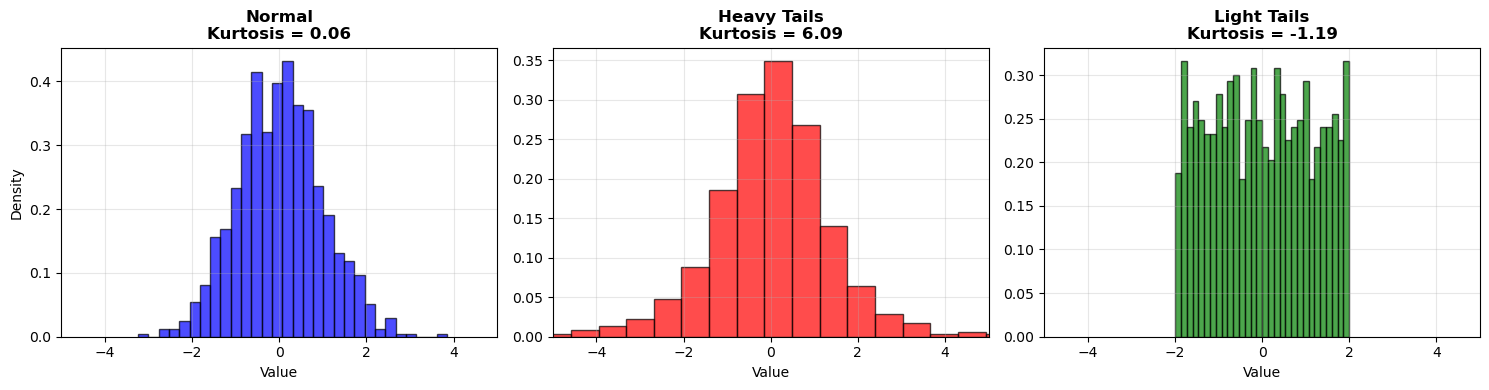

In [19]:
# Generate data with different kurtosis
np.random.seed(42)

# Normal (kurtosis ≈ 0)
normal_data = np.random.normal(0, 1, 1000)

# Heavy tails (Student's t)
heavy_tails = stats.t.rvs(df=3, size=1000)

# Light tails (uniform)
light_tails = np.random.uniform(-2, 2, 1000)

# Calculate kurtosis
_, _, _, kurt_normal = compute_moments(normal_data)
_, _, _, kurt_heavy = compute_moments(heavy_tails)
_, _, _, kurt_light = compute_moments(light_tails)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(normal_data, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title(f'Normal\nKurtosis = {kurt_normal:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-5, 5)
axes[0].grid(True, alpha=0.3)

axes[1].hist(heavy_tails, bins=30, density=True, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title(f'Heavy Tails\nKurtosis = {kurt_heavy:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_xlim(-5, 5)
axes[1].grid(True, alpha=0.3)

axes[2].hist(light_tails, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Light Tails\nKurtosis = {kurt_light:.2f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_xlim(-5, 5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🎮 Interactive Widget: Moments Explorer

In [20]:
moments_explorer_widget()

interactive(children=(FloatSlider(value=0.0, description='Skewness:', max=1.0, min=-1.0, style=SliderStyle(des…

# 🔗 Section 9: Covariance - Joint Distributions

## Covariance Definition

**Covariance** quantifies how two variables vary together:

$$\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

**Alternative form:** $\text{Cov}(X, Y) = E[XY] - E[X]E[Y]$

**Interpretation:**
- **Positive:** Large X tends to occur with large Y
- **Negative:** Large X tends to occur with small Y
- **Zero:** No linear relationship

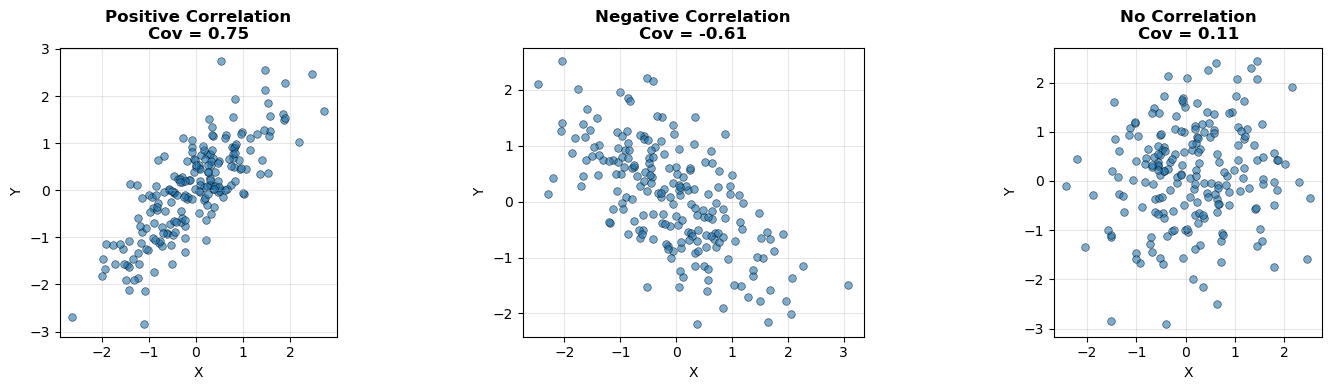

In [21]:
# Generate correlated data
np.random.seed(42)

# Positive correlation
x_pos, y_pos = generate_correlated_data(n_samples=200, correlation=0.8)

# Negative correlation
x_neg, y_neg = generate_correlated_data(n_samples=200, correlation=-0.7)

# No correlation
x_zero, y_zero = generate_correlated_data(n_samples=200, correlation=0.0)

# Calculate covariances
cov_pos = np.cov(x_pos, y_pos)[0, 1]
cov_neg = np.cov(x_neg, y_neg)[0, 1]
cov_zero = np.cov(x_zero, y_zero)[0, 1]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x_pos, y_pos, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title(f'Positive Correlation\nCov = {cov_pos:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].scatter(x_neg, y_neg, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'Negative Correlation\nCov = {cov_neg:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

axes[2].scatter(x_zero, y_zero, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'No Correlation\nCov = {cov_zero:.2f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### Covariance Matrix

For multiple variables, we organize covariances in a matrix:

$$\Sigma = \begin{bmatrix} \text{Var}(X_1) & \text{Cov}(X_1, X_2) \\ \text{Cov}(X_2, X_1) & \text{Var}(X_2) \end{bmatrix}$$

**Properties:**
- Diagonal elements are variances
- Off-diagonal elements are covariances
- Symmetric: $\Sigma = \Sigma^T$

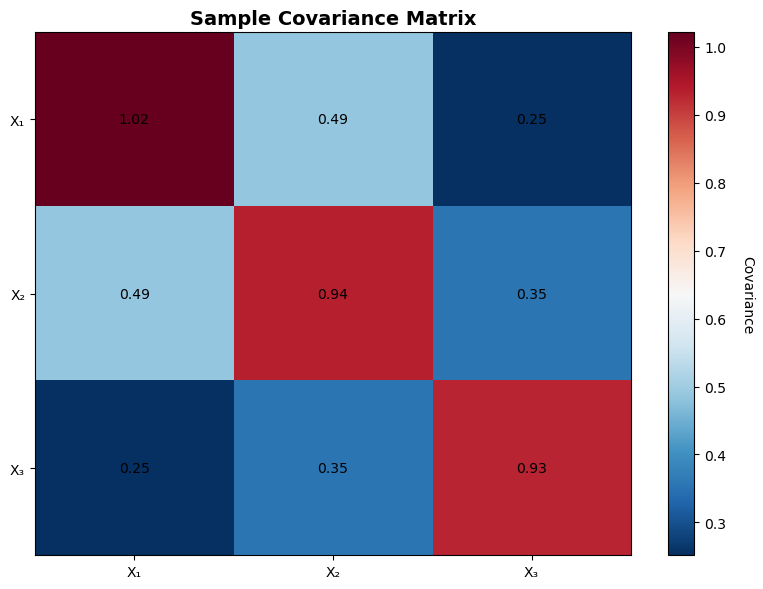

Covariance Matrix:
[[1.02152389 0.48626912 0.25153093]
 [0.48626912 0.93664978 0.354076  ]
 [0.25153093 0.354076   0.93009568]]


In [22]:
# Generate multivariate data
np.random.seed(42)
mean = [0, 0, 0]
cov_matrix = [[1.0, 0.5, 0.3],
              [0.5, 1.0, 0.4],
              [0.3, 0.4, 1.0]]

data = np.random.multivariate_normal(mean, cov_matrix, 1000)

# Calculate sample covariance matrix
sample_cov = np.cov(data.T)

# Visualize
fig, ax = plot_covariance_matrix(sample_cov, labels=['X₁', 'X₂', 'X₃'],
                                  title='Sample Covariance Matrix')
plt.show()

print("Covariance Matrix:")
print(sample_cov)

# 📐 Section 10: Correlation - Scale-Independent Measure

## Correlation Coefficient

**Correlation** is a normalized version of covariance:

$$\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

**Properties:**
- $-1 \leq \rho \leq 1$
- $\rho = 1$: Perfect positive linear relationship
- $\rho = -1$: Perfect negative linear relationship
- $\rho = 0$: No linear relationship

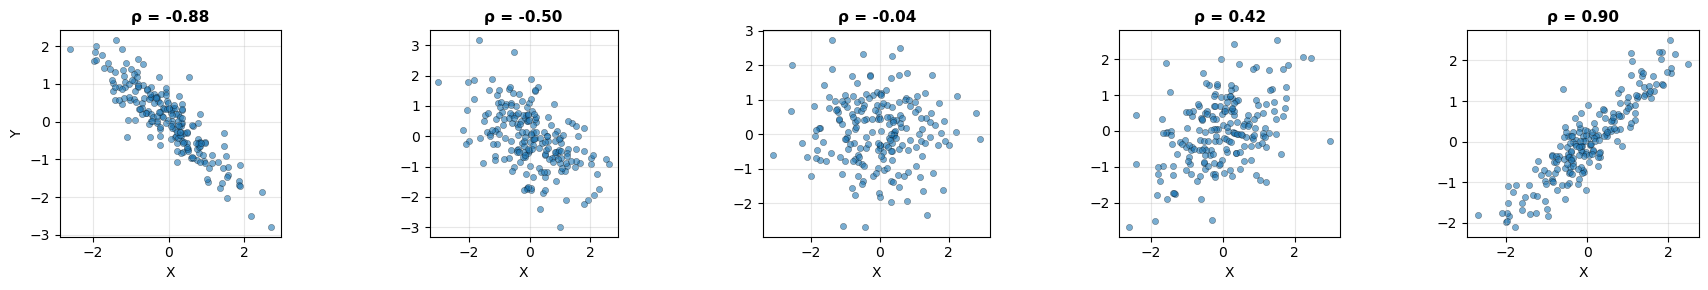

In [23]:
# Demonstrate correlation at different levels
correlations = [-0.9, -0.5, 0, 0.5, 0.9]
n_samples = 200

fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for i, rho in enumerate(correlations):
    x, y = generate_correlated_data(n_samples=n_samples, correlation=rho, seed=42+i)
    actual_rho = np.corrcoef(x, y)[0, 1]
    
    axes[i].scatter(x, y, alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
    axes[i].set_title(f'ρ = {actual_rho:.2f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('X', fontsize=10)
    if i == 0:
        axes[i].set_ylabel('Y', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()

### 🎮 Interactive Widget: Covariance Explorer

In [24]:
covariance_widget()

interactive(children=(FloatSlider(value=0.7, description='Correlation (ρ):', max=0.95, min=-0.95, step=0.05, s…

### 🎯 CE Example: Structural Loads

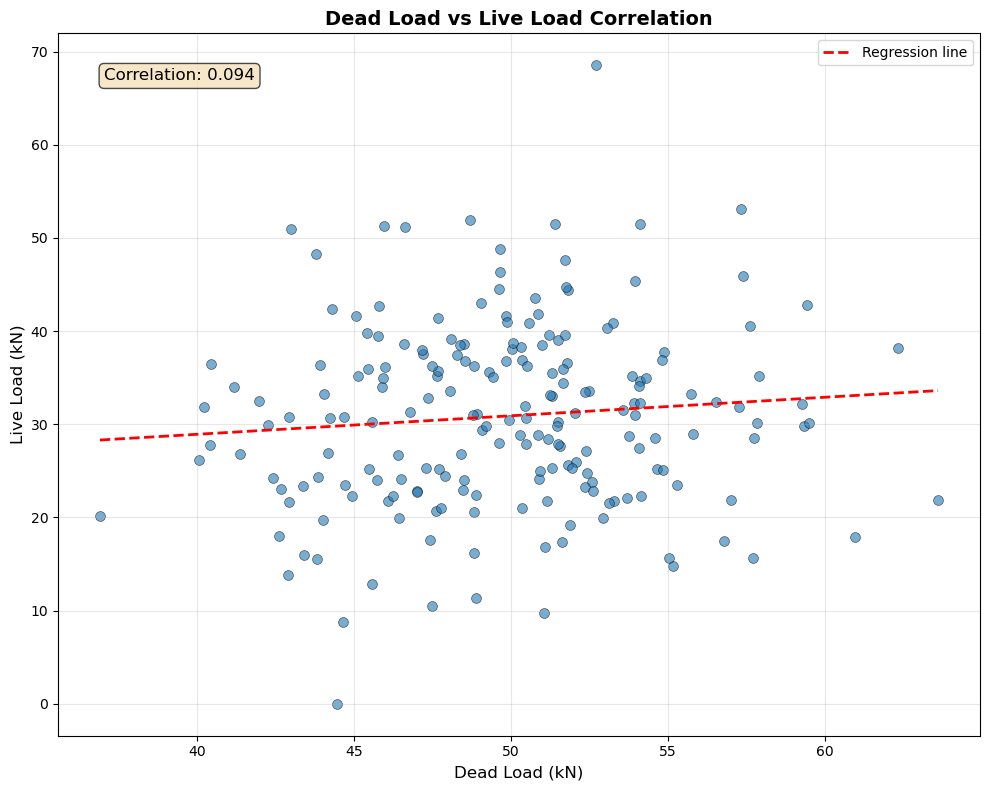

Structural Load Analysis:
  Dead load: mean = 49.80 kN, std = 4.66 kN
  Live load: mean = 30.87 kN, std = 9.83 kN
  Correlation: 0.094

Covariance Matrix:
[[21.66920725  4.30694076]
 [ 4.30694076 96.63999431]]


In [25]:
# Generate correlated dead and live loads
load_data = generate_load_data(n_samples=200, seed=42)

dead_loads = load_data['dead_loads']
live_loads = load_data['live_loads']
total_loads = load_data['total_loads']

# Plot correlation
fig, ax = plot_correlation_scatter(dead_loads, live_loads,
                                    title="Dead Load vs Live Load Correlation",
                                    xlabel="Dead Load (kN)",
                                    ylabel="Live Load (kN)")
plt.show()

print("Structural Load Analysis:")
print(f"  Dead load: mean = {np.mean(dead_loads):.2f} kN, std = {np.std(dead_loads, ddof=1):.2f} kN")
print(f"  Live load: mean = {np.mean(live_loads):.2f} kN, std = {np.std(live_loads, ddof=1):.2f} kN")
print(f"  Correlation: {load_data['info']['correlation']:.3f}")
print(f"\nCovariance Matrix:")
print(load_data['info']['covariance_matrix'])

# ⚡ Section 11: Extreme Value Distributions

## Why Extreme Values Matter

In Civil Engineering, we often care about **extremes**:
- Design for 100-year flood
- Maximum wind speed
- Minimum material strength
- Earthquake magnitude

**Problem:** Normal distribution underestimates extreme events!

$$ p(x) \propto \exp \left( -\frac{x^2}{2\sigma^2} \right) \text{(exponential decay)}$$

Extreme values are **extremely rare** in normal distribution.

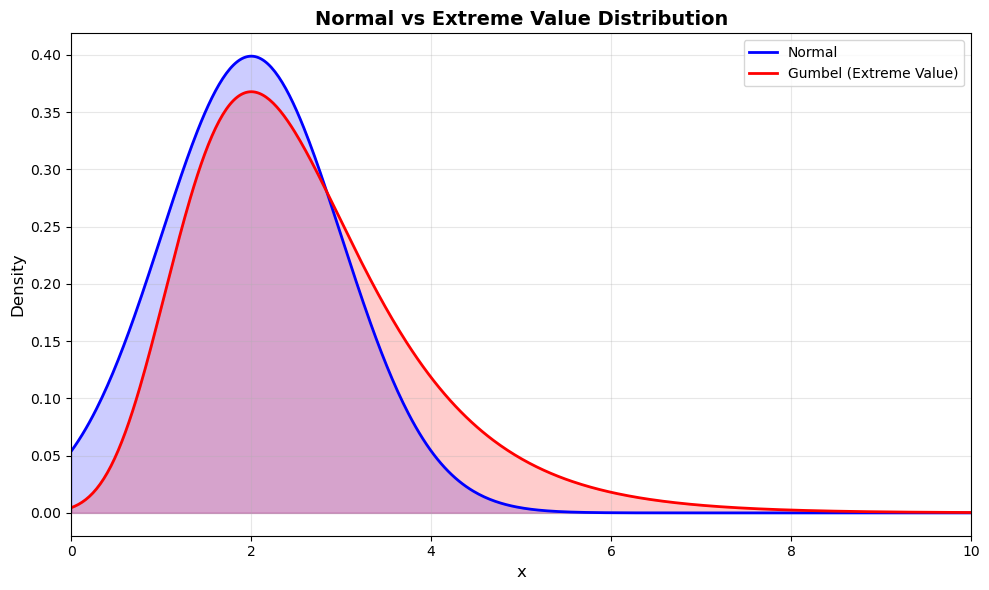

Tail Comparison (x > 5):
  Normal: P(X > 5) = 0.001350
  Gumbel: P(X > 5) = 0.048568

Gumbel has heavier tail → higher probability of extreme events!


In [26]:
# Compare normal vs extreme value tails
x = np.linspace(0, 10, 500)

# Normal
normal = normal_pdf(x, mu=2, sigma=1)

# Gumbel (extreme value)
gumbel = gumbel_pdf(x, mu=2, beta=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, normal, 'b-', linewidth=2, label='Normal')
ax.plot(x, gumbel, 'r-', linewidth=2, label='Gumbel (Extreme Value)')
ax.fill_between(x, normal, alpha=0.2, color='blue')
ax.fill_between(x, gumbel, alpha=0.2, color='red')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Normal vs Extreme Value Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

print("Tail Comparison (x > 5):")
print(f"  Normal: P(X > 5) = {1 - normal_cdf(5, 2, 1):.6f}")
print(f"  Gumbel: P(X > 5) = {1 - gumbel_cdf(5, 2, 1):.6f}")
print("\nGumbel has heavier tail → higher probability of extreme events!")

## Generalized Extreme Value (GEV) Distribution

The **GEV** unifies three extreme value distributions:

$$F(x; \mu, \sigma, \xi) = \exp\left(-(1 + \xi z)^{-1/\xi}\right)$$

where $z = \frac{x - \mu}{\sigma}$

**Shape parameter ξ determines type:**
- $\xi = 0$: **Gumbel** (Type I) - exponential tail
- $\xi > 0$: **Fréchet** (Type II) - heavy tail, no upper bound
- $\xi < 0$: **Weibull** (Type III) - bounded above

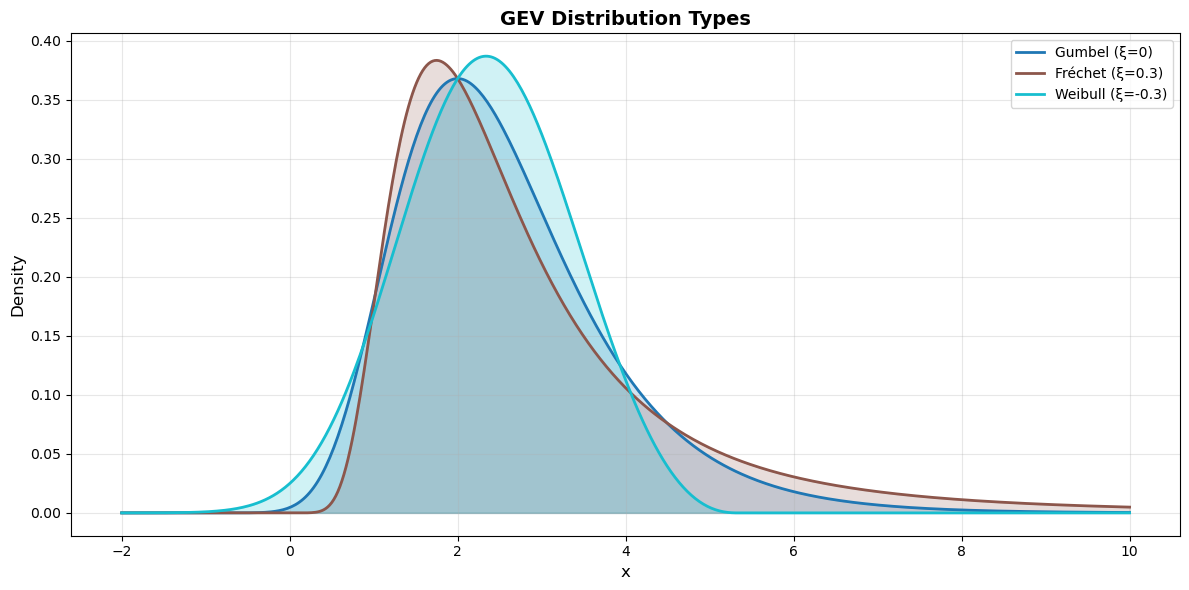

In [27]:
# Compare GEV types
x = np.linspace(-2, 10, 500)
mu, sigma = 2, 1

# Gumbel (xi = 0)
gumbel_pdf_vals = gumbel_pdf(x, mu, sigma)

# Fréchet (xi > 0)
frechet_pdf_vals = gev_pdf(x, mu, sigma, xi=0.3)

# Weibull (xi < 0)
weibull_pdf_vals = gev_pdf(x, mu, sigma, xi=-0.3)

fig, ax = plot_distribution_comparison(
    x,
    [gumbel_pdf_vals, frechet_pdf_vals, weibull_pdf_vals],
    ['Gumbel (ξ=0)', 'Fréchet (ξ=0.3)', 'Weibull (ξ=-0.3)'],
    title='GEV Distribution Types',
    xlabel='x'
)
plt.show()

### 🎮 Interactive Widget: Extreme Value Explorer

In [ ]:
extreme_value_widget()

interactive(children=(FloatSlider(value=0.0, description='Shape (ξ):', max=0.5, min=-0.5, step=0.05, style=Sli…

# 🏗️ Section 12: CE Applications

### Application 1: Concrete Strength Variability

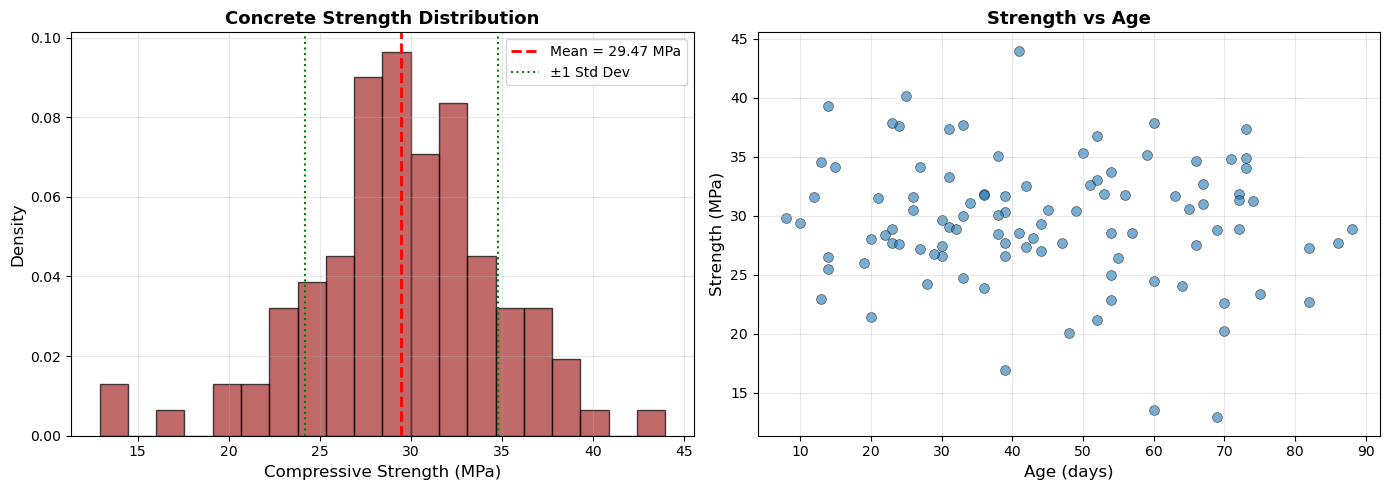

Concrete Strength Statistics:
  Mean: 29.47 MPa
  Std Dev: 5.30 MPa
  Coefficient of Variation: 17.98%
  Skewness: -0.352
  Kurtosis: 0.916


In [29]:
# Generate concrete strength data
concrete_data = generate_concrete_strength_data(n_samples=100, mean_strength=30, 
                                                std_strength=5, add_outliers=True, seed=42)

strengths = concrete_data['strengths']
ages = concrete_data['ages']

# Calculate moments
mean, var, skew, kurt = compute_moments(strengths)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(strengths, bins=20, density=True, alpha=0.7, color='brown', edgecolor='black')
ax1.axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean = {mean:.2f} MPa')
ax1.axvline(mean - np.sqrt(var), color='g', linestyle=':', linewidth=1.5)
ax1.axvline(mean + np.sqrt(var), color='g', linestyle=':', linewidth=1.5, label='±1 Std Dev')
ax1.set_xlabel('Compressive Strength (MPa)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Concrete Strength Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter: strength vs age
ax2.scatter(ages, strengths, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Age (days)', fontsize=12)
ax2.set_ylabel('Strength (MPa)', fontsize=12)
ax2.set_title('Strength vs Age', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Concrete Strength Statistics:")
print(f"  Mean: {mean:.2f} MPa")
print(f"  Std Dev: {np.sqrt(var):.2f} MPa")
print(f"  Coefficient of Variation: {np.sqrt(var)/mean:.2%}")
print(f"  Skewness: {skew:.3f}")
print(f"  Kurtosis: {kurt:.3f}")

### Application 2: Flood Frequency Analysis

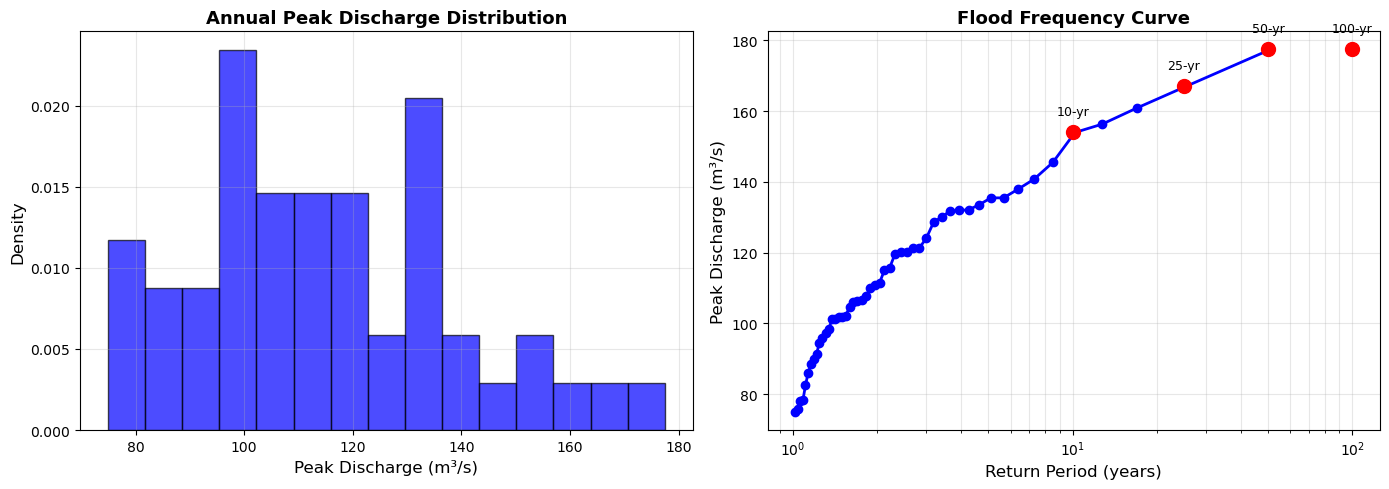

Flood Frequency Analysis:
  Mean annual peak: 115.18 m³/s
  Std deviation: 24.39 m³/s

Design Floods:
   10-year flood: 153.98 m³/s
   25-year flood: 167.05 m³/s
   50-year flood: 177.46 m³/s
  100-year flood: 177.46 m³/s


In [30]:
# Generate flood data
flood_data = generate_flood_data(n_years=50, location_param=100, scale_param=20,
                                 distribution='gumbel', seed=42)

discharges = flood_data['discharges']
sorted_discharges = flood_data['sorted_discharges']
return_periods = flood_data['return_periods']

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(discharges, bins=15, density=True, alpha=0.7, color='blue', edgecolor='black')
ax1.set_xlabel('Peak Discharge (m³/s)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Annual Peak Discharge Distribution', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Return period plot
ax2.semilogx(return_periods, sorted_discharges, 'bo-', linewidth=2, markersize=6)
ax2.set_xlabel('Return Period (years)', fontsize=12)
ax2.set_ylabel('Peak Discharge (m³/s)', fontsize=12)
ax2.set_title('Flood Frequency Curve', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Mark design floods
for T in [10, 25, 50, 100]:
    idx = np.argmin(np.abs(return_periods - T))
    Q = sorted_discharges[idx]
    ax2.plot(T, Q, 'ro', markersize=10)
    ax2.text(T, Q + 5, f'{T}-yr', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Flood Frequency Analysis:")
print(f"  Mean annual peak: {np.mean(discharges):.2f} m³/s")
print(f"  Std deviation: {np.std(discharges, ddof=1):.2f} m³/s")
print(f"\nDesign Floods:")
for T in [10, 25, 50, 100]:
    idx = np.argmin(np.abs(return_periods - T))
    Q = sorted_discharges[idx]
    print(f"  {T:3d}-year flood: {Q:.2f} m³/s")

### Application 3: Wind Speed Extremes

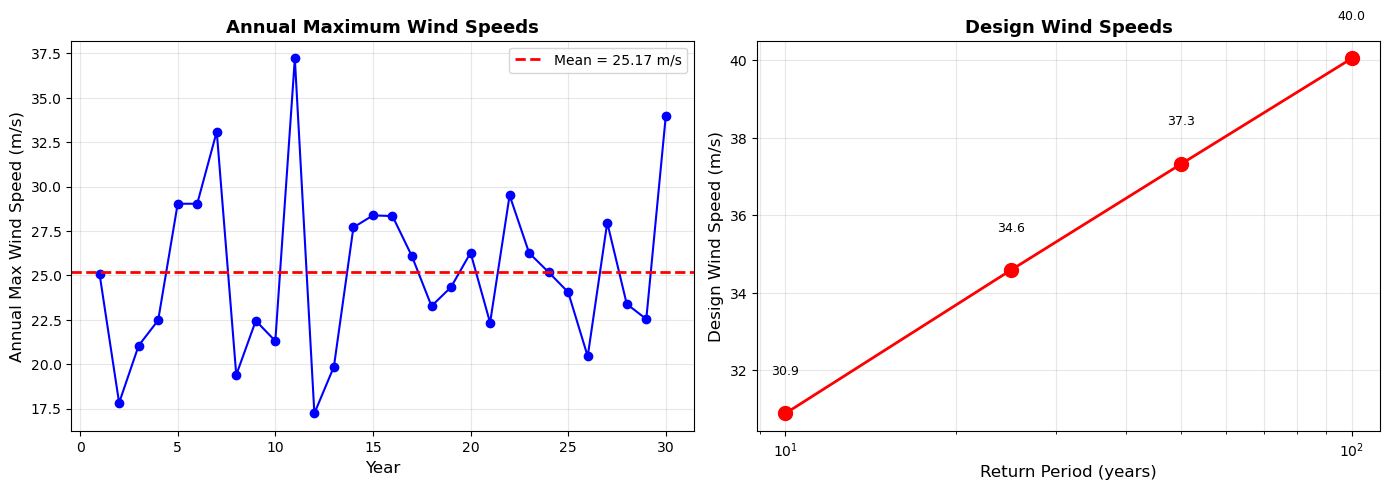

Wind Speed Analysis:
  Mean annual max: 25.17 m/s
  Std deviation: 4.71 m/s

Design Wind Speeds:
   10-year: 30.89 m/s
   25-year: 34.58 m/s
   50-year: 37.33 m/s
  100-year: 40.05 m/s


In [31]:
# Generate wind speed data
wind_data = generate_wind_speed_data(n_years=30, mean_speed=25, std_speed=5, seed=42)

annual_max_speeds = wind_data['annual_max_speeds']
design_speeds = wind_data['design_speeds']

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time series
years = np.arange(1, len(annual_max_speeds) + 1)
ax1.plot(years, annual_max_speeds, 'bo-', linewidth=1.5, markersize=6)
ax1.axhline(np.mean(annual_max_speeds), color='r', linestyle='--', 
           linewidth=2, label=f'Mean = {np.mean(annual_max_speeds):.2f} m/s')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Annual Max Wind Speed (m/s)', fontsize=12)
ax1.set_title('Annual Maximum Wind Speeds', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Design speeds
return_periods = [10, 25, 50, 100]
speeds = [design_speeds[f'{T}-year'] for T in return_periods]

ax2.semilogx(return_periods, speeds, 'ro-', linewidth=2, markersize=10)
ax2.set_xlabel('Return Period (years)', fontsize=12)
ax2.set_ylabel('Design Wind Speed (m/s)', fontsize=12)
ax2.set_title('Design Wind Speeds', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

for T, V in zip(return_periods, speeds):
    ax2.text(T, V + 1, f'{V:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Wind Speed Analysis:")
print(f"  Mean annual max: {np.mean(annual_max_speeds):.2f} m/s")
print(f"  Std deviation: {np.std(annual_max_speeds, ddof=1):.2f} m/s")
print(f"\nDesign Wind Speeds:")
for T in return_periods:
    V = design_speeds[f'{T}-year']
    print(f"  {T:3d}-year: {V:.2f} m/s")

### Application 4: Sensor Noise Analysis

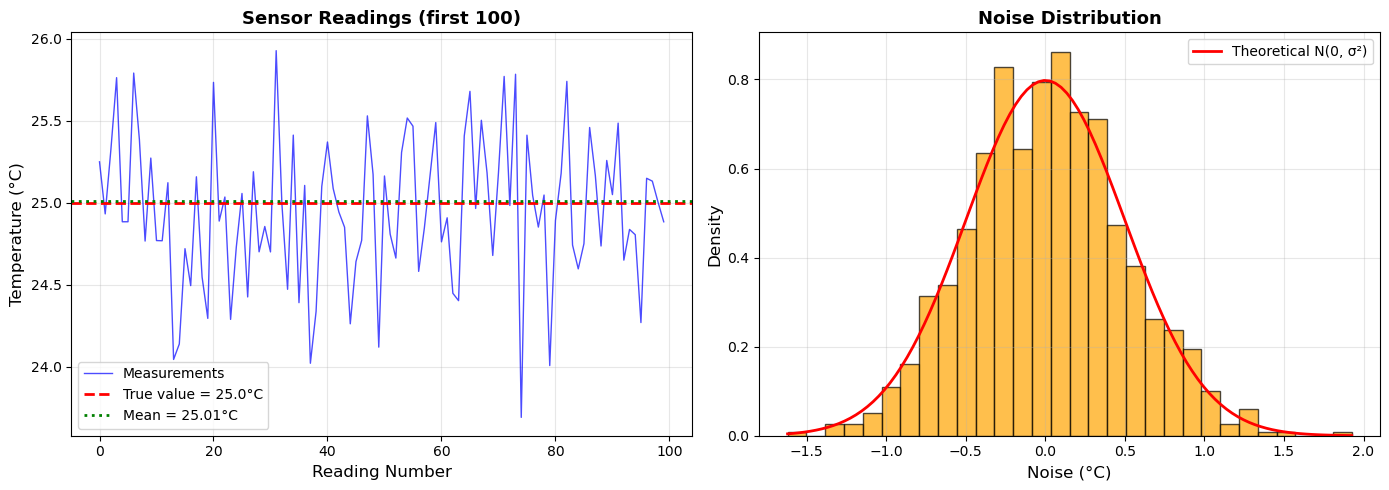

Sensor Noise Analysis:
  True value: 25.00°C
  Measured mean: 25.0097°C
  Measurement error: 0.0097°C
  Noise std (theoretical): 0.5000°C
  Noise std (measured): 0.4894°C


In [32]:
# Generate sensor data
sensor_data = generate_sensor_noise(n_readings=1000, true_value=25.0, 
                                    noise_std=0.5, noise_type='gaussian', seed=42)

readings = sensor_data['readings']
noise = sensor_data['noise']
true_value = sensor_data['true_value']

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time series
ax1.plot(readings[:100], 'b-', linewidth=1, alpha=0.7, label='Measurements')
ax1.axhline(true_value, color='r', linestyle='--', linewidth=2, label=f'True value = {true_value}°C')
ax1.axhline(np.mean(readings), color='g', linestyle=':', linewidth=2, 
           label=f'Mean = {np.mean(readings):.2f}°C')
ax1.set_xlabel('Reading Number', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Sensor Readings (first 100)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Noise distribution
ax2.hist(noise, bins=30, density=True, alpha=0.7, color='orange', edgecolor='black')

# Overlay normal distribution
x_noise = np.linspace(noise.min(), noise.max(), 100)
pdf_noise = normal_pdf(x_noise, 0, sensor_data['info']['noise_std'])
ax2.plot(x_noise, pdf_noise, 'r-', linewidth=2, label='Theoretical N(0, σ²)')

ax2.set_xlabel('Noise (°C)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Noise Distribution', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sensor Noise Analysis:")
print(f"  True value: {true_value:.2f}°C")
print(f"  Measured mean: {sensor_data['info']['measured_mean']:.4f}°C")
print(f"  Measurement error: {abs(sensor_data['info']['measured_mean'] - true_value):.4f}°C")
print(f"  Noise std (theoretical): {sensor_data['info']['noise_std']:.4f}°C")
print(f"  Noise std (measured): {sensor_data['info']['measured_std']:.4f}°C")

# 📚 Section 13: Summary & Key Takeaways

## 🎯 Key Concepts Covered

### 1. **Random Variables**
- Discrete vs continuous
- Mapping from sample space to real numbers

### 2. **Probability Functions**
- PMF for discrete RVs
- PDF for continuous RVs
- CDF for cumulative probabilities

### 3. **Common Distributions**
- Uniform: Complete uncertainty
- Normal: Most common in nature
- Gumbel/GEV: Extreme values

### 4. **Moments**
- **Mean (μ):** Center of distribution
- **Variance (σ²):** Spread around mean
- **Skewness:** Asymmetry
- **Kurtosis:** Tail heaviness

### 5. **Joint Distributions**
- **Covariance:** How variables vary together
- **Correlation:** Normalized covariance (-1 to 1)
- **Covariance matrix:** For multiple variables

### 6. **Extreme Values**
- Normal distribution underestimates extremes
- GEV distribution for maxima/minima
- Critical for safety-critical design

## 🔗 Connections to Machine Learning

| Probability Concept | ML Application |
|---------------------|----------------|
| Random Variables | Features, labels, predictions |
| PDF/PMF | Probabilistic classifiers |
| Expected Value | Loss function minimization |
| Variance | Model uncertainty, confidence intervals |
| Covariance | Feature correlation, PCA |
| Normal Distribution | Gaussian processes, noise models |
| Extreme Values | Outlier detection, robust ML |

## 💡 Key Insights for CE

1. **Design for Uncertainty:** Use probability to quantify safety margins
2. **Return Periods:** 100-year flood doesn't mean once per century!
3. **Tail Risk:** Extreme events matter more than averages
4. **Correlation Matters:** Dead and live loads may not be independent
5. **Data Quality:** Sensor noise follows probability distributions
6. **Robust Design:** Account for variability in materials and loads

## 📖 Further Reading

1. **Books:**
   - *Probability and Statistics for Engineers* by Miller & Freund
   - *An Introduction to Statistical Learning* by James et al.
   - *Extreme Value Theory* by Coles

2. **Online Resources:**
   - SciPy Stats Documentation
   - Khan Academy: Probability & Statistics
   - 3Blue1Brown: Probability videos

3. **Practice:**
   - Analyze real flood data
   - Fit distributions to material test data
   - Simulate Monte Carlo reliability analysis

## 🎓 Review Questions

1. What's the difference between PMF and PDF?
2. Why is P(X = x) = 0 for continuous distributions?
3. How does variance change when you scale a random variable?
4. What does correlation = 0 mean? Does it imply independence?
5. Why can't we use normal distribution for extreme events?
6. What's the difference between Gumbel, Fréchet, and Weibull?
7. How do you interpret a 100-year flood?
8. Why is covariance scale-dependent but correlation is not?

# 🎉 Congratulations!

You've completed the Probability & Statistics notebook!

**You should now understand:**
- ✓ Random variables and probability distributions
- ✓ Statistical moments (mean, variance, skewness, kurtosis)
- ✓ Covariance and correlation
- ✓ Extreme value distributions for CE design
- ✓ Applications to floods, wind, materials, and sensors

**Next Lecture:** Optimization and Loss Landscapes

---

*Notebook created for CE639: AI for Civil Engineering*  
*IIT Gandhinagar*